# AgriMind Phase 5: Guideline-Ready Reinforcement Learning Fertilizer Scheduling Agent

## Proposal objective covered

**Objective 3:** Develop a Reinforcement Learning agent to learn the optimal schedule of applying fertilizer to receive the maximum crop with minimum money.

## Why a simulated RL environment is used

For real reinforcement learning, the agent must repeatedly try actions and receive rewards. Real farm trial data for thousands of fertilizer application attempts is not available. Therefore, this notebook creates a simulated farming environment using realistic input conditions from the Phase 4 fertilizer dataset.

## Guideline items covered

- Source of dataset
- Dataset characteristics
- Data preprocessing
  - importing libraries
  - importing dataset
  - handling missing values
  - treating duplicate records
  - treating outliers
  - handling categorical variables
  - feature scaling
  - train/test split for evaluation states
- Feature selection approach
- RL environment design
- State space, action space, reward function
- Q-learning training
- Separate test evaluation
- Performance metrics
- Reward graphs, action visualizations, learned policy table
- Overfitting/underfitting style generalization check using train-vs-test reward
- Saved model artifacts, results, screenshots, and methodology report

In [1]:
# ============================================================
# Block 1: Import libraries and set environment
# ============================================================

import os
import sys
import json
import pickle
import subprocess
import warnings

warnings.filterwarnings("ignore")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn"
}

for import_name, package_name in required_packages.items():
    try:
        __import__(import_name)
    except ModuleNotFoundError:
        print(f"Installing missing package: {package_name}")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# ============================================================
# Block 2: Define exact project paths
# ============================================================

PROJECT_DIR = r"E:\AI Project\AgriMind_Project"

# Phase 4 dataset is used to initialize realistic crop, soil, nutrient, and fertilizer conditions.
PHASE4_DATASET_PATH = r"E:\AI Project\AgriMind_Project\datasets\Fertilizer_Recomendation_Dataset\Crop and fertilizer dataset.csv"

MODEL_DIR = r"E:\AI Project\AgriMind_Project\models\phase5_rl_guideline_ready_fertilizer_scheduling"
RESULTS_DIR = r"E:\AI Project\AgriMind_Project\results\phase5_rl_guideline_ready_fertilizer_scheduling"
SCREENSHOTS_DIR = r"E:\AI Project\AgriMind_Project\screenshots\phase5_rl_guideline_ready_fertilizer_scheduling"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(SCREENSHOTS_DIR, exist_ok=True)

print("Project directory exists:", os.path.exists(PROJECT_DIR))
print("Phase 4 dataset exists:", os.path.exists(PHASE4_DATASET_PATH))
print("Dataset path:", PHASE4_DATASET_PATH)
print("Model folder:", MODEL_DIR)
print("Results folder:", RESULTS_DIR)
print("Screenshots folder:", SCREENSHOTS_DIR)

if not os.path.exists(PHASE4_DATASET_PATH):
    raise FileNotFoundError(f"Dataset not found: {PHASE4_DATASET_PATH}")

Project directory exists: True
Phase 4 dataset exists: True
Dataset path: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Recomendation_Dataset\Crop and fertilizer dataset.csv
Model folder: E:\AI Project\AgriMind_Project\models\phase5_rl_guideline_ready_fertilizer_scheduling
Results folder: E:\AI Project\AgriMind_Project\results\phase5_rl_guideline_ready_fertilizer_scheduling
Screenshots folder: E:\AI Project\AgriMind_Project\screenshots\phase5_rl_guideline_ready_fertilizer_scheduling


In [3]:
# ============================================================
# Block 3: Import dataset
# ============================================================

df_original = pd.read_csv(PHASE4_DATASET_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df_original.shape)

display(df_original.head())
display(df_original.tail())

Dataset loaded successfully.
Dataset shape: (4513, 11)


,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Link
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo


,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Link
4508,Pune,Black,130,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4509,Pune,Black,135,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4510,Pune,Black,140,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4511,Pune,Black,145,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo
4512,Pune,Black,150,80,150,7.0,1400,30,Sugarcane,MOP,https://youtu.be/2t5Am0xLTOo


In [4]:
# ============================================================
# Block 4: Source of dataset and dataset characteristics
# ============================================================

DATASET_SOURCE = (
    "Kaggle: Crop and Fertilizer Dataset for Western Maharashtra. "
    "The dataset is used here to create realistic initial states for the simulated RL fertilizer scheduling environment."
)

dataset_characteristics = {
    "dataset_path": PHASE4_DATASET_PATH,
    "dataset_source": DATASET_SOURCE,
    "number_of_rows": int(df_original.shape[0]),
    "number_of_columns": int(df_original.shape[1]),
    "column_names": list(df_original.columns),
    "total_missing_values": int(df_original.isnull().sum().sum()),
    "duplicate_rows": int(df_original.duplicated().sum())
}

print(json.dumps(dataset_characteristics, indent=4))

{
    "dataset_path": "E:\\AI Project\\AgriMind_Project\\datasets\\Fertilizer_Recomendation_Dataset\\Crop and fertilizer dataset.csv",
    "dataset_source": "Kaggle: Crop and Fertilizer Dataset for Western Maharashtra. The dataset is used here to create realistic initial states for the simulated RL fertilizer scheduling environment.",
    "number_of_rows": 4513,
    "number_of_columns": 11,
    "column_names": [
        "District_Name",
        "Soil_color",
        "Nitrogen",
        "Phosphorus",
        "Potassium",
        "pH",
        "Rainfall",
        "Temperature",
        "Crop",
        "Fertilizer",
        "Link"
    ],
    "total_missing_values": 0,
    "duplicate_rows": 0
}


In [5]:
# ============================================================
# Block 5: Clean column names and remove duplicate records
# ============================================================

df = df_original.copy()

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace("/", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
    .str.replace(".", "_", regex=False)
)

rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]

duplicate_report = {
    "rows_before_duplicate_removal": int(rows_before),
    "rows_after_duplicate_removal": int(rows_after),
    "duplicate_rows_removed": int(rows_before - rows_after)
}

print("Cleaned columns:")
print(list(df.columns))

print("\nDuplicate record report:")
print(json.dumps(duplicate_report, indent=4))

Cleaned columns:
['district_name', 'soil_color', 'nitrogen', 'phosphorus', 'potassium', 'ph', 'rainfall', 'temperature', 'crop', 'fertilizer', 'link']

Duplicate record report:
{
    "rows_before_duplicate_removal": 4513,
    "rows_after_duplicate_removal": 4513,
    "duplicate_rows_removed": 0
}


In [6]:
# ============================================================
# Block 6: Handle missing values
# ============================================================

missing_before = df.isnull().sum()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    mode_value = df[col].mode()
    df[col] = df[col].fillna(mode_value[0] if len(mode_value) > 0 else "Unknown")

missing_after = df.isnull().sum()

missing_report = pd.DataFrame({
    "Missing_Before": missing_before,
    "Missing_After": missing_after
})

display(missing_report)
print("Remaining missing values:", int(df.isnull().sum().sum()))

,Missing_Before,Missing_After
district_name,0,0
soil_color,0,0
nitrogen,0,0
phosphorus,0,0
potassium,0,0
ph,0,0
rainfall,0,0
temperature,0,0
crop,0,0
fertilizer,0,0


Remaining missing values: 0


In [7]:
# ============================================================
# Block 7: Detect useful agricultural columns
# ============================================================

def find_col_by_keywords(columns, keywords):
    for col in columns:
        col_lower = col.lower()
        if any(keyword in col_lower for keyword in keywords):
            return col
    return None

nitrogen_col = find_col_by_keywords(df.columns, ["nitrogen"])
phosphorus_col = find_col_by_keywords(df.columns, ["phosphorus", "phosphorous"])
potassium_col = find_col_by_keywords(df.columns, ["potassium"])
ph_col = find_col_by_keywords(df.columns, ["ph"])
crop_col = find_col_by_keywords(df.columns, ["crop"])
soil_col = find_col_by_keywords(df.columns, ["soil"])
rainfall_col = find_col_by_keywords(df.columns, ["rainfall", "rain"])
temperature_col = find_col_by_keywords(df.columns, ["temperature", "temp"])
fertilizer_col = find_col_by_keywords(df.columns, ["fertilizer", "fertiliser"])

detected_columns = {
    "nitrogen": nitrogen_col,
    "phosphorus": phosphorus_col,
    "potassium": potassium_col,
    "ph": ph_col,
    "crop": crop_col,
    "soil": soil_col,
    "rainfall": rainfall_col,
    "temperature": temperature_col,
    "fertilizer": fertilizer_col
}

print("Detected columns:")
print(json.dumps(detected_columns, indent=4))

if fertilizer_col is None:
    raise ValueError("Fertilizer column was not detected.")

Detected columns:
{
    "nitrogen": "nitrogen",
    "phosphorus": "phosphorus",
    "potassium": "potassium",
    "ph": "phosphorus",
    "crop": "crop",
    "soil": "soil_color",
    "rainfall": "rainfall",
    "temperature": "temperature",
    "fertilizer": "fertilizer"
}


In [8]:
# ============================================================
# Block 8: Convert nutrient/environment columns safely
# ============================================================

nutrient_level_map = {
    "low": 0,
    "medium": 1,
    "moderate": 1,
    "high": 2,
    "very low": 0,
    "very high": 3
}

def convert_nutrient_column(series):
    mapped = series.astype(str).str.strip().str.lower().map(nutrient_level_map)
    numeric = pd.to_numeric(series, errors="coerce")
    final = numeric.fillna(mapped)

    if final.isnull().sum() > 0:
        if final.dropna().shape[0] > 0:
            final = final.fillna(final.median())
        else:
            final = final.fillna(0)

    return final

for col in [nitrogen_col, phosphorus_col, potassium_col]:
    if col is not None:
        df[col] = convert_nutrient_column(df[col])

for col in [ph_col, rainfall_col, temperature_col]:
    if col is not None:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df[col].fillna(df[col].median())

print("Nutrient/environment columns converted safely.")
display(df.head())

Nutrient/environment columns converted safely.


,district_name,soil_color,nitrogen,phosphorus,potassium,ph,rainfall,temperature,crop,fertilizer,link
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo


In [9]:
# ============================================================
# Block 9: Treat outliers in numerical columns
# ============================================================

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

outlier_report = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_before = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

    outliers_after = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_report.append({
        "Column": col,
        "Lower_Bound": float(lower_bound),
        "Upper_Bound": float(upper_bound),
        "Outliers_Before": int(outliers_before),
        "Outliers_After": int(outliers_after)
    })

outlier_report_df = pd.DataFrame(outlier_report)
display(outlier_report_df)

,Column,Lower_Bound,Upper_Bound,Outliers_Before,Outliers_After
0,nitrogen,-37.5,222.5,0,0
1,phosphorus,2.5,102.5,0,0
2,potassium,-12.5,127.5,495,0
3,ph,4.5,8.5,0,0
4,rainfall,0.0,1600.0,9,0
5,temperature,5.0,45.0,0,0


In [10]:
# ============================================================
# Block 10: Feature selection approach for RL environment
# ============================================================

# Feature selection logic:
# Keep crop/soil/nutrient/environment features because they affect fertilizer scheduling.
# Remove link/url/id-like columns because they do not help the RL state.

drop_keywords = ["link", "url", "id", "index", "serial", "no", "number"]

selected_feature_columns = []

for col in df.columns:
    col_lower = col.lower()

    if any(keyword == col_lower or keyword in col_lower for keyword in drop_keywords):
        continue

    if col == fertilizer_col:
        continue

    selected_feature_columns.append(col)

feature_selection_report = {
    "selected_features": selected_feature_columns,
    "removed_reason": "Removed target fertilizer column and link/url/id-like columns.",
    "purpose": "Selected features are used to construct RL environment states."
}

print(json.dumps(feature_selection_report, indent=4))

{
    "selected_features": [
        "district_name",
        "soil_color",
        "nitrogen",
        "phosphorus",
        "potassium",
        "ph",
        "rainfall",
        "temperature",
        "crop"
    ],
    "removed_reason": "Removed target fertilizer column and link/url/id-like columns.",
    "purpose": "Selected features are used to construct RL environment states."
}


In [11]:
# ============================================================
# Block 11: Handle categorical variables and feature scaling
# ============================================================

# Although Q-learning uses discrete states, the guideline requires categorical handling and scaling.
# We create a processed feature matrix for documentation, validation, and state preparation.

X_raw = df[selected_feature_columns].copy()

X_encoded = pd.get_dummies(X_raw, drop_first=False)

for col in X_encoded.columns:
    X_encoded[col] = pd.to_numeric(X_encoded[col], errors="coerce").fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Raw feature shape:", X_raw.shape)
print("Encoded feature shape:", X_encoded.shape)
print("Scaled feature matrix shape:", X_scaled.shape)

display(X_encoded.head())

Raw feature shape: (4513, 9)
Encoded feature shape: (4513, 34)
Scaled feature matrix shape: (4513, 34)


,nitrogen,phosphorus,potassium,ph,rainfall,temperature,district_name_Kolhapur,district_name_Pune,district_name_Sangli,district_name_Satara,...,crop_Maize,crop_Masoor,crop_Moong,crop_Rice,crop_Soybean,crop_Sugarcane,crop_Tur,crop_Turmeric,crop_Urad,crop_Wheat
0,75,50,100.0,6.5,1000,20,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,80,50,100.0,6.5,1000,20,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,85,50,100.0,6.5,1000,20,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,90,50,100.0,6.5,1000,20,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False
4,95,50,100.0,6.5,1000,20,True,False,False,False,...,False,False,False,False,False,True,False,False,False,False


In [12]:
# ============================================================
# Block 12: Create discrete RL state variables
# ============================================================

df_rl = df.copy()

# Nutrient need:
# Low NPK total means high fertilizer need.
if nitrogen_col and phosphorus_col and potassium_col:
    df_rl["npk_total"] = df_rl[nitrogen_col] + df_rl[phosphorus_col] + df_rl[potassium_col]
else:
    df_rl["npk_total"] = np.random.uniform(0, 3, size=len(df_rl))

q1 = df_rl["npk_total"].quantile(0.33)
q2 = df_rl["npk_total"].quantile(0.66)

def nutrient_need_from_npk(value):
    if value <= q1:
        return 2   # high need
    elif value <= q2:
        return 1   # medium need
    else:
        return 0   # low need

df_rl["nutrient_need_level"] = df_rl["npk_total"].apply(nutrient_need_from_npk)

# Price level is simulated because real future fertilizer price data is not available in this dataset.
# It represents the economic part of the proposal.
df_rl["price_level"] = np.random.choice([0, 1, 2], size=len(df_rl), p=[0.35, 0.40, 0.25])

def simulate_crop_health(nutrient_need):
    if nutrient_need == 2:
        return np.random.choice([0, 1], p=[0.65, 0.35])
    elif nutrient_need == 1:
        return np.random.choice([0, 1, 2], p=[0.25, 0.55, 0.20])
    else:
        return np.random.choice([1, 2], p=[0.35, 0.65])

df_rl["crop_health_level"] = df_rl["nutrient_need_level"].apply(simulate_crop_health)

# Growth stage:
# 0 = early, 1 = middle, 2 = late
df_rl["growth_stage"] = np.random.choice([0, 1, 2], size=len(df_rl), p=[0.35, 0.45, 0.20])

state_columns = [
    "nutrient_need_level",
    "price_level",
    "crop_health_level",
    "growth_stage"
]

print("RL state columns:", state_columns)
display(df_rl[state_columns + [fertilizer_col]].head())

RL state columns: ['nutrient_need_level', 'price_level', 'crop_health_level', 'growth_stage']


,nutrient_need_level,price_level,crop_health_level,growth_stage,fertilizer
0,1,1,1,1,Urea
1,1,2,1,0,Urea
2,1,1,1,2,Urea
3,1,1,1,1,Urea
4,1,0,2,0,Urea


In [13]:
# ============================================================
# Block 13: Train-test split for RL evaluation states
# ============================================================

# RL does not use train-test split exactly like supervised learning.
# Here, we split the initial environment states:
# - train states are used for Q-learning training starts
# - test states are held out for final greedy-policy evaluation

train_states_df, test_states_df = train_test_split(
    df_rl,
    test_size=0.20,
    random_state=42,
    stratify=df_rl["nutrient_need_level"]
)

print("Training environment state rows:", train_states_df.shape[0])
print("Testing environment state rows:", test_states_df.shape[0])

print("\nTraining nutrient need distribution:")
display(train_states_df["nutrient_need_level"].value_counts().sort_index())

print("\nTesting nutrient need distribution:")
display(test_states_df["nutrient_need_level"].value_counts().sort_index())

Training environment state rows: 3610
Testing environment state rows: 903

Training nutrient need distribution:


nutrient_need_level
0    1130
1    1215
2    1265
Name: count, dtype: int64


Testing nutrient need distribution:


nutrient_need_level
0    282
1    304
2    317
Name: count, dtype: int64

In [14]:
# ============================================================
# Block 14: Define RL state and action spaces
# ============================================================

# State format:
# (nutrient_need_level, price_level, crop_health_level, growth_stage)
#
# nutrient_need_level: 0 low, 1 medium, 2 high
# price_level: 0 low, 1 medium, 2 high
# crop_health_level: 0 poor, 1 average, 2 good
# growth_stage: 0 early, 1 middle, 2 late

actions = {
    0: "Do nothing",
    1: "Apply low fertilizer amount",
    2: "Apply normal fertilizer amount",
    3: "Apply high fertilizer amount",
    4: "Wait because fertilizer price is high"
}

num_actions = len(actions)

all_states = []

for nutrient_need in range(3):
    for price_level in range(3):
        for crop_health in range(3):
            for growth_stage in range(3):
                all_states.append((nutrient_need, price_level, crop_health, growth_stage))

state_to_index = {state: idx for idx, state in enumerate(all_states)}
index_to_state = {idx: state for state, idx in state_to_index.items()}

num_states = len(all_states)

print("Number of states:", num_states)
print("Number of actions:", num_actions)
print("Actions:")
for action_id, action_name in actions.items():
    print(action_id, ":", action_name)

Number of states: 81
Number of actions: 5
Actions:
0 : Do nothing
1 : Apply low fertilizer amount
2 : Apply normal fertilizer amount
3 : Apply high fertilizer amount
4 : Wait because fertilizer price is high


In [29]:
# ============================================================
# Block 15: Define reward function - SAFER AGRICULTURAL VERSION
# ============================================================

def calculate_reward(state, action):
    nutrient_need, price_level, crop_health, growth_stage = state

    reward = 0.0

    # Higher fertilizer price means higher cost
    price_multiplier = [1.0, 1.5, 2.2][price_level]

    action_cost = {
        0: 0.0,   # Do nothing
        1: 1.0,   # Low amount
        2: 2.0,   # Normal amount
        3: 3.0,   # High amount
        4: 0.2    # Wait
    }[action] * price_multiplier

    # --------------------------------------------------------
    # Main fertilizer decision reward
    # --------------------------------------------------------

    if nutrient_need == 0:
        # Low nutrient need: avoid fertilizer
        if action == 0:
            reward += 8
        elif action == 4:
            reward += 5
        elif action == 1:
            reward -= 2
        elif action == 2:
            reward -= 8
        elif action == 3:
            reward -= 12

    elif nutrient_need == 1:
        # Medium nutrient need: normal amount is best
        if action == 0:
            reward -= 4
        elif action == 1:
            reward += 6
        elif action == 2:
            reward += 10
        elif action == 3:
            reward -= 8   # stronger penalty for over-application
        elif action == 4:
            reward += 2 if price_level == 2 else -2

    elif nutrient_need == 2:
        # High nutrient need: normal or high amount depending on condition
        if action == 0:
            reward -= 10
        elif action == 1:
            reward += 3
        elif action == 2:
            reward += 10
        elif action == 3:
            # High amount is useful only if crop health is poor and not late stage
            if crop_health == 0 and growth_stage in [0, 1]:
                reward += 12
            else:
                reward += 5
        elif action == 4:
            reward += 2 if price_level == 2 else -6

    # --------------------------------------------------------
    # Crop health adjustment
    # --------------------------------------------------------

    if crop_health == 0 and action == 0:
        reward -= 6

    if crop_health == 2 and action == 3:
        reward -= 8

    # --------------------------------------------------------
    # Growth stage adjustment
    # --------------------------------------------------------

    if growth_stage == 2 and action == 3:
        reward -= 8

    if growth_stage == 2 and action == 2:
        reward -= 2

    if growth_stage in [0, 1] and nutrient_need == 2 and action in [2, 3]:
        reward += 2

    # --------------------------------------------------------
    # Fertilizer cost penalty
    # --------------------------------------------------------

    reward -= action_cost

    return reward

example_state = (2, 0, 0, 1)
print("Example state:", example_state)
for action_id, action_name in actions.items():
    print(action_name, "reward:", calculate_reward(example_state, action_id))

Example state: (2, 0, 0, 1)
Do nothing reward: -16.0
Apply low fertilizer amount reward: 2.0
Apply normal fertilizer amount reward: 10.0
Apply high fertilizer amount reward: 11.0
Wait because fertilizer price is high reward: -6.2


In [30]:
# ============================================================
# Block 16: Define environment transition function
# ============================================================

def next_state_after_action(state, action):
    nutrient_need, price_level, crop_health, growth_stage = state

    # Fertilizer application improves nutrient condition.
    if action == 1:
        nutrient_need = max(0, nutrient_need - 1)
    elif action == 2:
        nutrient_need = max(0, nutrient_need - 1)
        crop_health = min(2, crop_health + 1)
    elif action == 3:
        nutrient_need = max(0, nutrient_need - 2)
        crop_health = min(2, crop_health + 1)
    elif action == 0:
        if nutrient_need == 2:
            crop_health = max(0, crop_health - 1)
    elif action == 4:
        # Waiting may reduce price later, but nutrient condition may not improve.
        pass

    # Price changes randomly over time.
    if np.random.rand() < 0.35:
        price_level = np.random.choice([0, 1, 2], p=[0.35, 0.40, 0.25])

    # Growth stage progresses over time.
    if np.random.rand() < 0.20:
        growth_stage = min(2, growth_stage + 1)

    return (nutrient_need, price_level, crop_health, growth_stage)

In [31]:
# ============================================================
# Block 17: Initialize Q-learning parameters
# ============================================================

Q_table = np.zeros((num_states, num_actions))

learning_rate = 0.10
discount_factor = 0.95
epsilon = 1.0
epsilon_decay = 0.995
min_epsilon = 0.05

episodes = 6000
max_steps_per_episode = 20

episode_rewards = []

print("Q-table shape:", Q_table.shape)
print("Episodes:", episodes)
print("Max steps per episode:", max_steps_per_episode)

Q-table shape: (81, 5)
Episodes: 6000
Max steps per episode: 20


In [32]:
# ============================================================
# Block 18: Train Q-learning agent
# ============================================================

for episode in range(episodes):
    sample_row = train_states_df.sample(1).iloc[0]

    state = (
        int(sample_row["nutrient_need_level"]),
        int(sample_row["price_level"]),
        int(sample_row["crop_health_level"]),
        int(sample_row["growth_stage"])
    )

    total_reward = 0.0

    for step in range(max_steps_per_episode):
        state_index = state_to_index[state]

        # Epsilon-greedy exploration.
        if np.random.rand() < epsilon:
            action = np.random.choice(list(actions.keys()))
        else:
            action = int(np.argmax(Q_table[state_index]))

        reward = calculate_reward(state, action)
        next_state = next_state_after_action(state, action)
        next_state_index = state_to_index[next_state]

        old_q = Q_table[state_index, action]
        best_next_q = np.max(Q_table[next_state_index])

        new_q = old_q + learning_rate * (
            reward + discount_factor * best_next_q - old_q
        )

        Q_table[state_index, action] = new_q

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)
    epsilon = max(min_epsilon, epsilon * epsilon_decay)

print("Training completed.")
print("Final epsilon:", epsilon)
print("Final average reward of last 100 episodes:", np.mean(episode_rewards[-100:]))

Training completed.
Final epsilon: 0.05
Final average reward of last 100 episodes: 130.3576


In [34]:
# ============================================================
# Block 19: Evaluation helper functions
# ============================================================

def greedy_policy_action(state):
    state_index = state_to_index[state]
    return int(np.argmax(Q_table[state_index]))

def random_policy_action(state):
    return int(np.random.choice(list(actions.keys())))

def evaluate_policy(initial_states_df, policy_type="greedy", episodes_to_evaluate=500, max_steps=20):
    total_rewards = []
    action_counts = {action_id: 0 for action_id in actions.keys()}

    for _ in range(episodes_to_evaluate):
        sample_row = initial_states_df.sample(1).iloc[0]

        state = (
            int(sample_row["nutrient_need_level"]),
            int(sample_row["price_level"]),
            int(sample_row["crop_health_level"]),
            int(sample_row["growth_stage"])
        )

        episode_reward = 0.0

        for _ in range(max_steps):
            if policy_type == "greedy":
                action = greedy_policy_action(state)
            elif policy_type == "random":
                action = random_policy_action(state)
            else:
                raise ValueError("policy_type must be 'greedy' or 'random'.")

            action_counts[action] += 1

            reward = calculate_reward(state, action)
            state = next_state_after_action(state, action)
            episode_reward += reward

        total_rewards.append(episode_reward)

    return {
        "average_reward": float(np.mean(total_rewards)),
        "std_reward": float(np.std(total_rewards)),
        "min_reward": float(np.min(total_rewards)),
        "max_reward": float(np.max(total_rewards)),
        "total_rewards": total_rewards,
        "action_counts": action_counts
    }

In [35]:
# ============================================================
# Block 20: Evaluate learned policy on train and test states
# ============================================================

train_eval = evaluate_policy(train_states_df, policy_type="greedy", episodes_to_evaluate=500)
test_eval = evaluate_policy(test_states_df, policy_type="greedy", episodes_to_evaluate=500)
random_test_eval = evaluate_policy(test_states_df, policy_type="random", episodes_to_evaluate=500)

print("Greedy policy train average reward:", train_eval["average_reward"])
print("Greedy policy test average reward:", test_eval["average_reward"])
print("Random policy test average reward:", random_test_eval["average_reward"])

test_improvement_over_random = test_eval["average_reward"] - random_test_eval["average_reward"]

print("Test reward improvement over random policy:", test_improvement_over_random)

Greedy policy train average reward: 145.56495999999999
Greedy policy test average reward: 145.5044
Random policy test average reward: -122.33208
Test reward improvement over random policy: 267.83648


In [36]:
# ============================================================
# Block 21: Overfitting / underfitting style RL generalization check
# ============================================================

train_reward = train_eval["average_reward"]
test_reward = test_eval["average_reward"]

reward_gap = train_reward - test_reward
relative_gap = abs(reward_gap) / max(abs(train_reward), 1e-6)

if test_eval["average_reward"] <= random_test_eval["average_reward"]:
    fit_status = "Possible underfitting: learned policy does not outperform random policy on test states."
elif relative_gap > 0.25 and train_reward > test_reward:
    fit_status = "Possible overfitting: train reward is much higher than test reward."
else:
    fit_status = "No strong overfitting/underfitting sign: learned policy generalizes to held-out test states."

fit_check_df = pd.DataFrame([{
    "Train_Average_Reward": train_reward,
    "Test_Average_Reward": test_reward,
    "Random_Test_Average_Reward": random_test_eval["average_reward"],
    "Test_Improvement_Over_Random": test_improvement_over_random,
    "Train_Test_Reward_Gap": reward_gap,
    "Relative_Gap": relative_gap,
    "Diagnosis": fit_status
}])

display(fit_check_df)

fit_check_path = os.path.join(RESULTS_DIR, "phase5_rl_overfitting_underfitting_check.csv")
fit_check_df.to_csv(fit_check_path, index=False)

print("RL fit check saved at:", fit_check_path)

,Train_Average_Reward,Test_Average_Reward,Random_Test_Average_Reward,Test_Improvement_Over_Random,Train_Test_Reward_Gap,Relative_Gap,Diagnosis
0,145.56496,145.5044,-122.33208,267.83648,0.06056,0.000416,No strong overfitting/underfitting sign: learn...


RL fit check saved at: E:\AI Project\AgriMind_Project\results\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_rl_overfitting_underfitting_check.csv


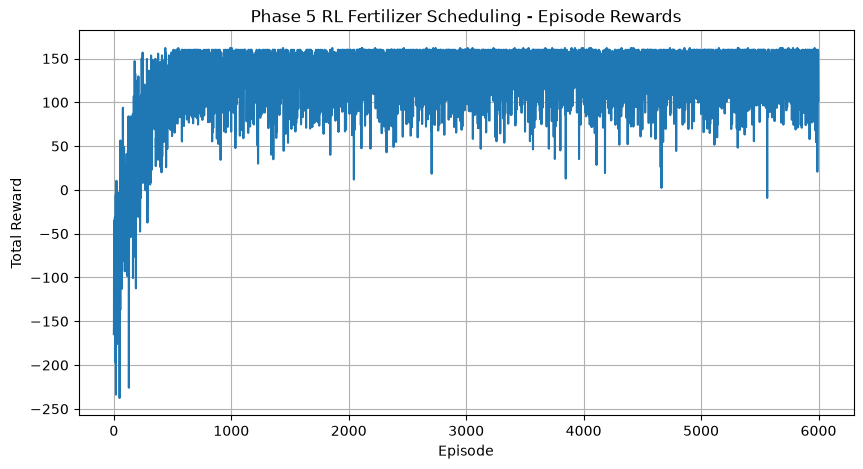

Reward graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_rl_episode_rewards.png


In [37]:
# ============================================================
# Block 22: Plot training rewards
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards)
plt.title("Phase 5 RL Fertilizer Scheduling - Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)

reward_graph_path = os.path.join(SCREENSHOTS_DIR, "phase5_rl_episode_rewards.png")
plt.savefig(reward_graph_path, dpi=300, bbox_inches="tight")
plt.show()

print("Reward graph saved at:", reward_graph_path)

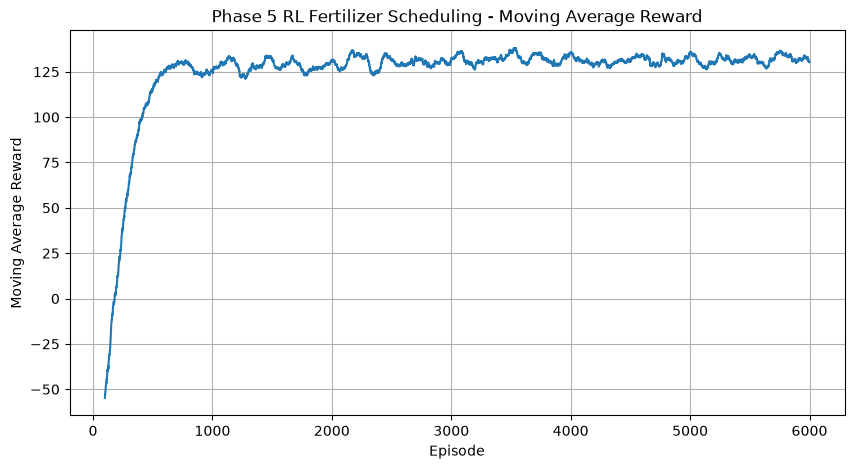

Moving average reward graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_rl_moving_average_reward.png


In [38]:
# ============================================================
# Block 23: Plot moving average reward
# ============================================================

window_size = 100
moving_average_rewards = pd.Series(episode_rewards).rolling(window=window_size).mean()

plt.figure(figsize=(10, 5))
plt.plot(moving_average_rewards)
plt.title("Phase 5 RL Fertilizer Scheduling - Moving Average Reward")
plt.xlabel("Episode")
plt.ylabel("Moving Average Reward")
plt.grid(True)

moving_avg_graph_path = os.path.join(SCREENSHOTS_DIR, "phase5_rl_moving_average_reward.png")
plt.savefig(moving_avg_graph_path, dpi=300, bbox_inches="tight")
plt.show()

print("Moving average reward graph saved at:", moving_avg_graph_path)

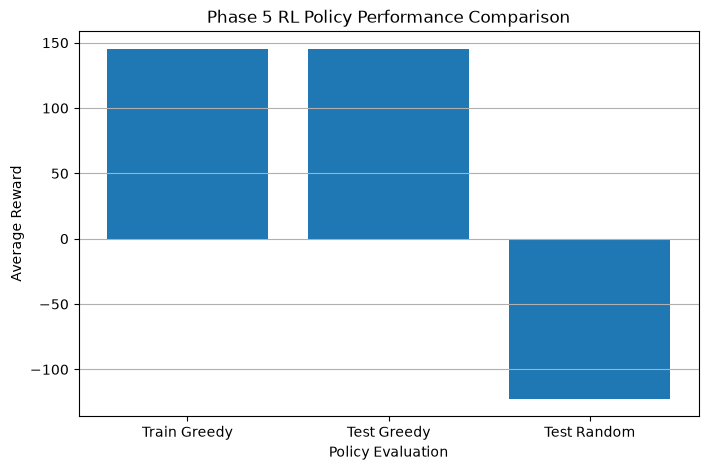

Policy reward comparison graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_rl_policy_reward_comparison.png


In [39]:
# ============================================================
# Block 24: Plot train vs test vs random policy reward comparison
# ============================================================

comparison_labels = ["Train Greedy", "Test Greedy", "Test Random"]
comparison_values = [
    train_eval["average_reward"],
    test_eval["average_reward"],
    random_test_eval["average_reward"]
]

plt.figure(figsize=(8, 5))
plt.bar(comparison_labels, comparison_values)
plt.title("Phase 5 RL Policy Performance Comparison")
plt.xlabel("Policy Evaluation")
plt.ylabel("Average Reward")
plt.grid(axis="y")

policy_comparison_path = os.path.join(SCREENSHOTS_DIR, "phase5_rl_policy_reward_comparison.png")
plt.savefig(policy_comparison_path, dpi=300, bbox_inches="tight")
plt.show()

print("Policy reward comparison graph saved at:", policy_comparison_path)

In [40]:
# ============================================================
# Block 25: Generate learned policy table
# ============================================================

policy_rows = []

for state in all_states:
    state_index = state_to_index[state]
    best_action_id = int(np.argmax(Q_table[state_index]))
    best_action_name = actions[best_action_id]

    nutrient_need, price_level, crop_health, growth_stage = state

    policy_rows.append({
        "Nutrient_Need_Level": nutrient_need,
        "Price_Level": price_level,
        "Crop_Health_Level": crop_health,
        "Growth_Stage": growth_stage,
        "Best_Action_ID": best_action_id,
        "Best_Action": best_action_name,
        "Best_Q_Value": float(np.max(Q_table[state_index]))
    })

policy_df = pd.DataFrame(policy_rows)

display(policy_df.head(20))

policy_path = os.path.join(RESULTS_DIR, "phase5_rl_learned_policy_table.csv")
policy_df.to_csv(policy_path, index=False)

print("Learned policy table saved at:", policy_path)

,Nutrient_Need_Level,Price_Level,Crop_Health_Level,Growth_Stage,Best_Action_ID,Best_Action,Best_Q_Value
0,0,0,0,0,2,Apply normal fertilizer amount,57.958438
1,0,0,0,1,2,Apply normal fertilizer amount,116.400446
2,0,0,0,2,4,Wait because fertilizer price is high,85.276090
3,0,0,1,0,4,Wait because fertilizer price is high,130.325101
4,0,0,1,1,3,Apply high fertilizer amount,137.000000
5,0,0,1,2,3,Apply high fertilizer amount,129.000000
6,0,0,2,0,0,Do nothing,160.000000
7,0,0,2,1,0,Do nothing,160.000000
8,0,0,2,2,0,Do nothing,160.000000
9,0,1,0,0,3,Apply high fertilizer amount,58.518028


Learned policy table saved at: E:\AI Project\AgriMind_Project\results\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_rl_learned_policy_table.csv


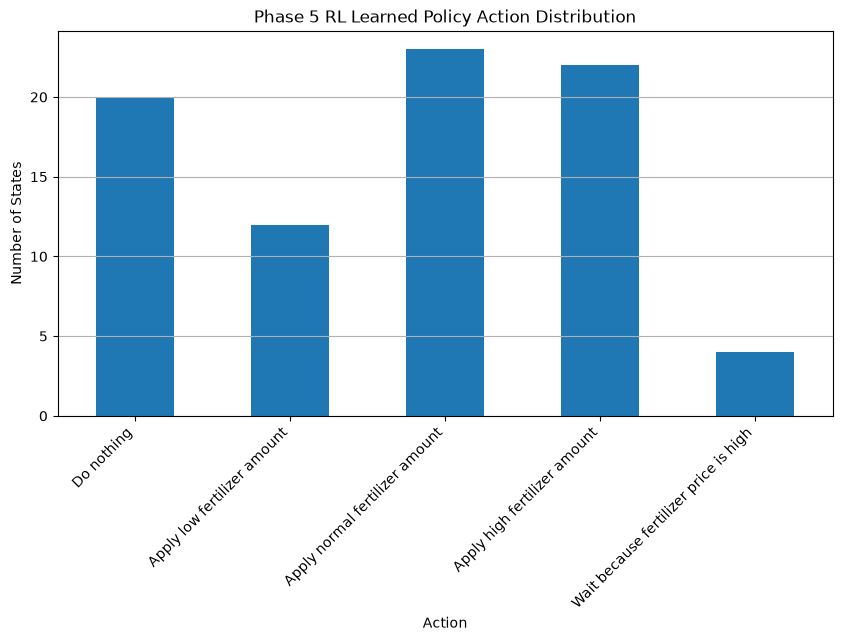

Action distribution graph saved at: E:\AI Project\AgriMind_Project\screenshots\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_rl_action_distribution.png


Best_Action
Do nothing                               20
Apply low fertilizer amount              12
Apply normal fertilizer amount           23
Apply high fertilizer amount             22
Wait because fertilizer price is high     4
Name: count, dtype: int64

In [41]:
# ============================================================
# Block 26: Action distribution visualization
# ============================================================

action_distribution = policy_df["Best_Action"].value_counts().reindex(actions.values(), fill_value=0)

plt.figure(figsize=(10, 5))
action_distribution.plot(kind="bar")
plt.title("Phase 5 RL Learned Policy Action Distribution")
plt.xlabel("Action")
plt.ylabel("Number of States")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")

action_distribution_path = os.path.join(SCREENSHOTS_DIR, "phase5_rl_action_distribution.png")
plt.savefig(action_distribution_path, dpi=300, bbox_inches="tight")
plt.show()

print("Action distribution graph saved at:", action_distribution_path)
display(action_distribution)

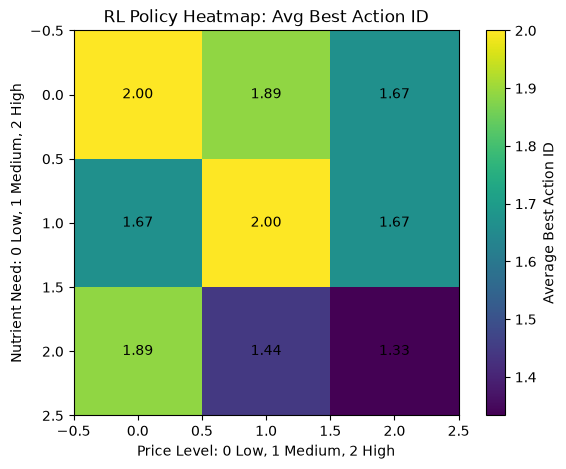

Policy heatmap saved at: E:\AI Project\AgriMind_Project\screenshots\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_rl_policy_heatmap.png


In [42]:
# ============================================================
# Block 27: Policy heatmap-style visualization
# ============================================================

# This is a visualization equivalent for the RL policy.
# A normal confusion matrix is not suitable because RL is not supervised classification.

heatmap_data = np.zeros((3, 3))

# Average best action ID by nutrient need and price level.
for nutrient_need in range(3):
    for price_level in range(3):
        subset = policy_df[
            (policy_df["Nutrient_Need_Level"] == nutrient_need) &
            (policy_df["Price_Level"] == price_level)
        ]
        heatmap_data[nutrient_need, price_level] = subset["Best_Action_ID"].mean()

plt.figure(figsize=(7, 5))
plt.imshow(heatmap_data)
plt.title("RL Policy Heatmap: Avg Best Action ID")
plt.xlabel("Price Level: 0 Low, 1 Medium, 2 High")
plt.ylabel("Nutrient Need: 0 Low, 1 Medium, 2 High")
plt.colorbar(label="Average Best Action ID")

for i in range(3):
    for j in range(3):
        plt.text(j, i, f"{heatmap_data[i, j]:.2f}", ha="center", va="center")

policy_heatmap_path = os.path.join(SCREENSHOTS_DIR, "phase5_rl_policy_heatmap.png")
plt.savefig(policy_heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Policy heatmap saved at:", policy_heatmap_path)

In [43]:
# ============================================================
# Block 28: Test RL agent with example states
# ============================================================

state_label_maps = {
    "nutrient_need_level": {0: "Low need", 1: "Medium need", 2: "High need"},
    "price_level": {0: "Low price", 1: "Medium price", 2: "High price"},
    "crop_health_level": {0: "Poor health", 1: "Average health", 2: "Good health"},
    "growth_stage": {0: "Early stage", 1: "Middle stage", 2: "Late stage"}
}

test_states = [
    (2, 0, 0, 1),
    (2, 2, 0, 1),
    (0, 2, 2, 2),
    (1, 1, 1, 1),
    (0, 0, 2, 0),
    (1, 2, 0, 2),
    (2, 1, 1, 0)
]

test_results = []

for state in test_states:
    state_index = state_to_index[state]
    best_action_id = int(np.argmax(Q_table[state_index]))
    best_action_name = actions[best_action_id]

    nutrient_need, price_level, crop_health, growth_stage = state

    test_results.append({
        "Nutrient Need": state_label_maps["nutrient_need_level"][nutrient_need],
        "Price Level": state_label_maps["price_level"][price_level],
        "Crop Health": state_label_maps["crop_health_level"][crop_health],
        "Growth Stage": state_label_maps["growth_stage"][growth_stage],
        "Recommended Action": best_action_name,
        "Q Value": float(np.max(Q_table[state_index]))
    })

test_results_df = pd.DataFrame(test_results)

display(test_results_df)

test_results_path = os.path.join(RESULTS_DIR, "phase5_rl_test_recommendations.csv")
test_results_df.to_csv(test_results_path, index=False)

print("Test recommendations saved at:", test_results_path)

,Nutrient Need,Price Level,Crop Health,Growth Stage,Recommended Action,Q Value
0,High need,Low price,Poor health,Middle stage,Apply high fertilizer amount,139.743413
1,High need,High price,Poor health,Middle stage,Apply high fertilizer amount,133.811274
2,Low need,High price,Good health,Late stage,Do nothing,160.000000
3,Medium need,Medium price,Average health,Middle stage,Apply normal fertilizer amount,158.999990
4,Low need,Low price,Good health,Early stage,Do nothing,160.000000
5,Medium need,High price,Poor health,Late stage,Apply low fertilizer amount,67.929753
6,High need,Medium price,Average health,Early stage,Apply normal fertilizer amount,157.968885


Test recommendations saved at: E:\AI Project\AgriMind_Project\results\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_rl_test_recommendations.csv


In [44]:
# ============================================================
# Block 29: Create recommendation function for demo
# ============================================================

def recommend_fertilizer_schedule(nutrient_need_level, price_level, crop_health_level, growth_stage):
    state = (
        int(nutrient_need_level),
        int(price_level),
        int(crop_health_level),
        int(growth_stage)
    )

    state_index = state_to_index[state]
    best_action_id = int(np.argmax(Q_table[state_index]))

    return {
        "state": state,
        "nutrient_need": state_label_maps["nutrient_need_level"][state[0]],
        "price_level": state_label_maps["price_level"][state[1]],
        "crop_health": state_label_maps["crop_health_level"][state[2]],
        "growth_stage": state_label_maps["growth_stage"][state[3]],
        "recommended_action_id": best_action_id,
        "recommended_action": actions[best_action_id],
        "q_value": float(np.max(Q_table[state_index]))
    }

demo_result = recommend_fertilizer_schedule(
    nutrient_need_level=2,
    price_level=1,
    crop_health_level=0,
    growth_stage=1
)

print("Demo RL recommendation:")
print(json.dumps(demo_result, indent=4))

Demo RL recommendation:
{
    "state": [
        2,
        1,
        0,
        1
    ],
    "nutrient_need": "High need",
    "price_level": "Medium price",
    "crop_health": "Poor health",
    "growth_stage": "Middle stage",
    "recommended_action_id": 3,
    "recommended_action": "Apply high fertilizer amount",
    "q_value": 138.76984604343068
}


In [45]:
# ============================================================
# Block 30: Save Q-table, scaler, mappings, and RL model data
# ============================================================

q_table_path = os.path.join(MODEL_DIR, "phase5_q_table.npy")
np.save(q_table_path, Q_table)

state_mapping_path = os.path.join(MODEL_DIR, "phase5_state_mappings.pkl")
with open(state_mapping_path, "wb") as f:
    pickle.dump({
        "state_to_index": state_to_index,
        "index_to_state": index_to_state,
        "actions": actions,
        "state_label_maps": state_label_maps
    }, f)

scaler_path = os.path.join(MODEL_DIR, "phase5_feature_scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)

encoded_columns_path = os.path.join(MODEL_DIR, "phase5_encoded_feature_columns.json")
with open(encoded_columns_path, "w") as f:
    json.dump(list(X_encoded.columns), f, indent=4)

episode_rewards_path = os.path.join(RESULTS_DIR, "phase5_episode_rewards.csv")
pd.DataFrame({
    "Episode": list(range(1, len(episode_rewards) + 1)),
    "Total_Reward": episode_rewards
}).to_csv(episode_rewards_path, index=False)

print("Q-table saved at:", q_table_path)
print("State/action mappings saved at:", state_mapping_path)
print("Feature scaler saved at:", scaler_path)
print("Encoded feature columns saved at:", encoded_columns_path)
print("Episode rewards saved at:", episode_rewards_path)

Q-table saved at: E:\AI Project\AgriMind_Project\models\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_q_table.npy
State/action mappings saved at: E:\AI Project\AgriMind_Project\models\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_state_mappings.pkl
Feature scaler saved at: E:\AI Project\AgriMind_Project\models\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_feature_scaler.pkl
Encoded feature columns saved at: E:\AI Project\AgriMind_Project\models\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_encoded_feature_columns.json
Episode rewards saved at: E:\AI Project\AgriMind_Project\results\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_episode_rewards.csv


In [46]:
# ============================================================
# Block 31: Save experimental results summary
# ============================================================

initial_avg_reward = float(np.mean(episode_rewards[:100]))
final_avg_reward = float(np.mean(episode_rewards[-100:]))
reward_improvement = final_avg_reward - initial_avg_reward

phase5_results = pd.DataFrame([{
    "Phase": "Phase 5",
    "Module": "Guideline-Ready RL Fertilizer Scheduling Agent",
    "Algorithm": "Q-learning",
    "Number_of_States": num_states,
    "Number_of_Actions": num_actions,
    "Episodes": episodes,
    "Max_Steps_Per_Episode": max_steps_per_episode,
    "Initial_Average_Reward_First_100": initial_avg_reward,
    "Final_Average_Reward_Last_100": final_avg_reward,
    "Reward_Improvement": reward_improvement,
    "Train_Average_Reward": train_eval["average_reward"],
    "Test_Average_Reward": test_eval["average_reward"],
    "Random_Test_Average_Reward": random_test_eval["average_reward"],
    "Test_Improvement_Over_Random": test_improvement_over_random,
    "Final_Epsilon": epsilon,
    "Fit_Diagnosis": fit_status
}])

results_path = os.path.join(RESULTS_DIR, "phase5_rl_fertilizer_scheduling_results.csv")
phase5_results.to_csv(results_path, index=False)

display(phase5_results)

print("Phase 5 results saved at:", results_path)

,Phase,Module,Algorithm,Number_of_States,Number_of_Actions,Episodes,Max_Steps_Per_Episode,Initial_Average_Reward_First_100,Final_Average_Reward_Last_100,Reward_Improvement,Train_Average_Reward,Test_Average_Reward,Random_Test_Average_Reward,Test_Improvement_Over_Random,Final_Epsilon,Fit_Diagnosis
0,Phase 5,Guideline-Ready RL Fertilizer Scheduling Agent,Q-learning,81,5,6000,20,-54.8066,130.3576,185.1642,145.56496,145.5044,-122.33208,267.83648,0.05,No strong overfitting/underfitting sign: learn...


Phase 5 results saved at: E:\AI Project\AgriMind_Project\results\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_rl_fertilizer_scheduling_results.csv


In [47]:
# ============================================================
# Block 32: Save preprocessing and methodology report
# ============================================================

phase5_report = {
    "phase": "Phase 5",
    "objective": "Reinforcement Learning fertilizer scheduling agent",
    "dataset_source": DATASET_SOURCE,
    "dataset_characteristics": dataset_characteristics,
    "why_simulated_environment": (
        "Real farm trial-and-error fertilizer scheduling data is not available. "
        "Therefore, a simulated RL environment was designed using realistic agricultural features "
        "from the Phase 4 fertilizer dataset. The objective is to learn a strategy that improves crop condition "
        "while reducing fertilizer cost and avoiding unnecessary fertilizer use."
    ),
    "preprocessing_steps": {
        "importing_libraries": True,
        "importing_dataset": True,
        "duplicate_removal": duplicate_report,
        "missing_values": "Median for numerical features and mode for categorical features",
        "outlier_treatment": "IQR clipping for numerical features",
        "categorical_handling": "One-hot encoding for documentation and environment feature matrix",
        "feature_scaling": "StandardScaler applied to encoded feature matrix",
        "train_test_split": "80% environment states for training starts, 20% held-out states for testing",
        "feature_selection": feature_selection_report,
        "state_creation": "nutrient need, price level, crop health level, and growth stage"
    },
    "rl_environment": {
        "states": {
            "nutrient_need_level": "0 low, 1 medium, 2 high",
            "price_level": "0 low, 1 medium, 2 high",
            "crop_health_level": "0 poor, 1 average, 2 good",
            "growth_stage": "0 early, 1 middle, 2 late"
        },
        "actions": actions,
        "reward_function": (
            "Reward increases when the action matches nutrient need and improves crop condition. "
            "Reward decreases for high cost, over-application, under-application, late excessive application, "
            "and unnecessary fertilizer use."
        )
    },
    "algorithm": {
        "name": "Q-learning",
        "learning_rate": learning_rate,
        "discount_factor": discount_factor,
        "initial_epsilon": 1.0,
        "epsilon_decay": epsilon_decay,
        "minimum_epsilon": min_epsilon,
        "episodes": episodes,
        "max_steps_per_episode": max_steps_per_episode
    },
    "evaluation_metrics": [
        "Initial average reward",
        "Final average reward",
        "Reward improvement",
        "Train average reward",
        "Test average reward",
        "Random policy baseline reward",
        "Test improvement over random policy",
        "Train-test reward gap",
        "Policy action distribution",
        "Learned policy table"
    ],
    "experimental_results": {
        "initial_average_reward_first_100": initial_avg_reward,
        "final_average_reward_last_100": final_avg_reward,
        "reward_improvement": reward_improvement,
        "train_average_reward": train_eval["average_reward"],
        "test_average_reward": test_eval["average_reward"],
        "random_test_average_reward": random_test_eval["average_reward"],
        "test_improvement_over_random": test_improvement_over_random,
        "fit_diagnosis": fit_status,
        "final_epsilon": epsilon
    },
    "visualizations": {
        "reward_graph": reward_graph_path,
        "moving_average_reward_graph": moving_avg_graph_path,
        "policy_reward_comparison": policy_comparison_path,
        "action_distribution": action_distribution_path,
        "policy_heatmap": policy_heatmap_path
    },
    "outputs": {
        "q_table": q_table_path,
        "policy_table": policy_path,
        "test_recommendations": test_results_path,
        "results_csv": results_path
    }
}

report_path = os.path.join(RESULTS_DIR, "phase5_preprocessing_methodology_experiment_report.json")

with open(report_path, "w") as f:
    json.dump(phase5_report, f, indent=4)

print("Phase 5 methodology and experiment report saved at:", report_path)

Phase 5 methodology and experiment report saved at: E:\AI Project\AgriMind_Project\results\phase5_rl_guideline_ready_fertilizer_scheduling\phase5_preprocessing_methodology_experiment_report.json


In [48]:
# ============================================================
# Block 33: Final Phase 5 summary
# ============================================================

print("============================================================")
print("AgriMind Phase 5 Guideline-Ready RL Fertilizer Scheduling Agent Completed")
print("============================================================")
print("Dataset:", PHASE4_DATASET_PATH)
print("RL algorithm: Q-learning")
print("Number of states:", num_states)
print("Number of actions:", num_actions)
print("Episodes:", episodes)
print("Initial average reward first 100 episodes:", initial_avg_reward)
print("Final average reward last 100 episodes:", final_avg_reward)
print("Reward improvement:", reward_improvement)
print("Train average reward:", train_eval["average_reward"])
print("Test average reward:", test_eval["average_reward"])
print("Random test average reward:", random_test_eval["average_reward"])
print("Test improvement over random:", test_improvement_over_random)
print("Fit diagnosis:", fit_status)
print("Model folder:", MODEL_DIR)
print("Results folder:", RESULTS_DIR)
print("Screenshots folder:", SCREENSHOTS_DIR)
print("============================================================")

if reward_improvement > 0 and test_improvement_over_random > 0:
    print("RL agent learned successfully: reward improved and learned policy beats random policy.")
else:
    print("RL learning is weak. Review reward function, increase training episodes, or adjust state/action design.")

AgriMind Phase 5 Guideline-Ready RL Fertilizer Scheduling Agent Completed
Dataset: E:\AI Project\AgriMind_Project\datasets\Fertilizer_Recomendation_Dataset\Crop and fertilizer dataset.csv
RL algorithm: Q-learning
Number of states: 81
Number of actions: 5
Episodes: 6000
Initial average reward first 100 episodes: -54.80660000000001
Final average reward last 100 episodes: 130.3576
Reward improvement: 185.1642
Train average reward: 145.56495999999999
Test average reward: 145.5044
Random test average reward: -122.33208
Test improvement over random: 267.83648
Fit diagnosis: No strong overfitting/underfitting sign: learned policy generalizes to held-out test states.
Model folder: E:\AI Project\AgriMind_Project\models\phase5_rl_guideline_ready_fertilizer_scheduling
Results folder: E:\AI Project\AgriMind_Project\results\phase5_rl_guideline_ready_fertilizer_scheduling
Screenshots folder: E:\AI Project\AgriMind_Project\screenshots\phase5_rl_guideline_ready_fertilizer_scheduling
RL agent learned s